Playground de tensorflow para "jugar" un poco y enteder de forma visual que es una red neuronal.

https://playground.tensorflow.org

In [1]:
%pip install tensorflow matplotlib numpy scikit-learn ultralytics

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached numpy-2.4.6-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached wrapt-2.2.1-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
  Using ca

In [4]:
import sys
try:
    sys.stdout.reconfigure(encoding='utf-8')
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print('TensorFlow :', tf.__version__)
print('Keras      :', keras.__version__)
print('NumPy      :', np.__version__)
print('Todo OK. (La CPU es suficiente para la clase de hoy.)')

TensorFlow : 2.21.0
Keras      : 3.14.1
NumPy      : 2.4.6
Todo OK. (La CPU es suficiente para la clase de hoy.)


MNIST = 70000 imágenes de dígitos del 0-9 

Imagenes de entrenamiento: (60000, 28, 28)
Etiquetas de entrenamiento: (60000,)
Imagenes de test: (10000, 28, 28)
Primeras 10 etiquetas: [5 0 4 1 9 2 1 3 1 4]


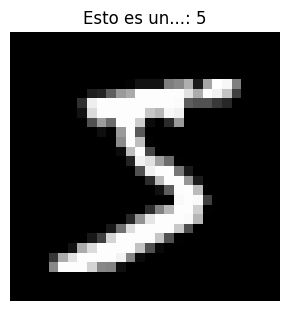

In [5]:
# Cargamos el dataset de MNIST
# keras.datasets.mnist.load_data() devuelve dos tuplas: la primera contiene los datos de entrenamiento (X_train, y_train)
# y la segunda contiene los datos de prueba (X_test, y_test).

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print('Imagenes de entrenamiento:', X_train.shape)
print('Etiquetas de entrenamiento:', y_train.shape)
print('Imagenes de test:', X_test.shape)
print('Primeras 10 etiquetas:', y_train[:10])

plt.figure(figsize=(3.5, 3.5))
plt.imshow(X_train[0], cmap='gray')
plt.title(f'Esto es un...: {str(y_train[0])}')
plt.axis('off')
plt.show()


In [6]:
print(X_train[0][4:16, 6:20])
print()
print("Cada pixel tiene un valor entre 0 y 255, donde 0 representa el color negro y 255 representa el color blanco. Los valores intermedios representan diferentes tonos de gris.")

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   3  18  18  18 126 136 175  26]
 [  0   0  30  36  94 154 170 253 253 253 253 253 225 172]
 [  0  49 238 253 253 253 253 253 253 253 253 251  93  82]
 [  0  18 219 253 253 253 253 253 198 182 247 241   0   0]
 [  0   0  80 156 107 253 253 205  11   0  43 154   0   0]
 [  0   0   0  14   1 154 253  90   0   0   0   0   0   0]
 [  0   0   0   0   0 139 253 190   2   0   0   0   0   0]
 [  0   0   0   0   0  11 190 253  70   0   0   0   0   0]
 [  0   0   0   0   0   0  35 241 225 160 108   1   0   0]
 [  0   0   0   0   0   0   0  81 240 253 253 119  25   0]
 [  0   0   0   0   0   0   0   0  45 186 253 253 150  27]]

Cada pixel tiene un valor entre 0 y 255, donde 0 representa el color negro y 255 representa el color blanco. Los valores intermedios representan diferentes tonos de gris.


In [7]:
X_train = X_train /255.0
X_test = X_test /255.0
print('Listo. Ahora los datos están normalizados.', X_train.min(), 'a', X_train.max())

Listo. Ahora los datos están normalizados. 0.0 a 1.0


In [8]:
modelo = keras.Sequential([

    keras.layers.Input(shape=(28, 28)), # ENTRADA: Imagenes de 28x28 pixeles
    keras.layers.Flatten(), # APLANAR, convierte la matriz de 28x28 en una fila de 784 elementos numeros
                            # (las capas DENSE necesitan trabajar con vectores)

    keras.layers.Dense(128, activation='relu'),  # CAPA OCULTA "densa": 128 neuronas conectadas al 784 del vector.
                                                 # DENSE = Cada neurona se conecta a TODAS las entradas.
                                                 # activacion relu es la "chispa" no lineal que permite aprender formas complejas
                                                 # sin ella la red solo sabría hacer rectas.
           
    keras.layers.Dense(10, activation='softmax') # CAPA DE SALIDA: 10 neuronas (una por digito  0-9).
                                                 # softmax convierte las 10 salidas en probabilidades que suman 1.
])


modelo.compile(
    optimizer='adam', # Adam # es un algoritmo de optimización que ajusta los pesos de la red para minimizar la función de pérdida.
    loss='sparse_categorical_crossentropy', # Función de pérdida para clasificación multi-clase
    metrics=['accuracy'] # Métrica para evaluar el rendimiento
)
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# fit es el método que se encarga de entrenar el modelo. Toma los datos de entrenamiento (X_train, y_train) y los utiliza para ajustar los pesos de la red neuronal.
# Entrenamos el modelo con los datos de entrenamiento, durante 5 épocas, y reservamos el 10% de los datos para validación.
historia = modelo.fit(X_train, y_train, epochs=5, validation_split=0.1)  

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9218 - loss: 0.2765 - val_accuracy: 0.9667 - val_loss: 0.1247
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9640 - loss: 0.1207 - val_accuracy: 0.9713 - val_loss: 0.0961
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9754 - loss: 0.0827 - val_accuracy: 0.9757 - val_loss: 0.0921
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9810 - loss: 0.0625 - val_accuracy: 0.9787 - val_loss: 0.0757
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9850 - loss: 0.0478 - val_accuracy: 0.9782 - val_loss: 0.0748


In [10]:
# evaluate es el método que se encarga de evaluar el rendimiento del modelo en un conjunto de datos de prueba (X_test, y_test).
# Devuelve la pérdida y la precisión.
# verbose=0 es para que no imprima el progreso de la evaluación.

test_acc = modelo.evaluate(X_test, y_test, verbose=0)[1]
print('Accuracy en test:', test_acc * 100, '%')
print('Es decir: acierta', round(test_acc*100), 'de cada 100 digitos que nunca habia visto')

Accuracy en test: 97.79000282287598 %
Es decir: acierta 98 de cada 100 digitos que nunca habia visto


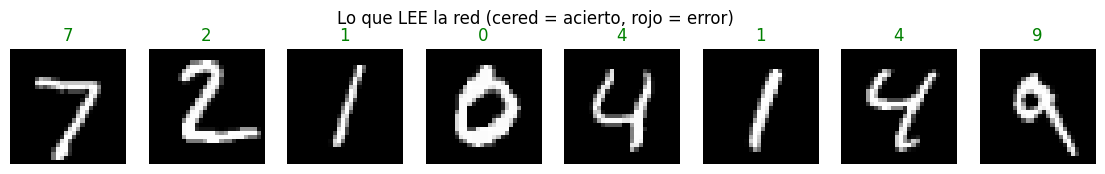

In [ ]:
# predict es el método que se encarga de hacer predicciones con el modelo entrenado. Toma un conjunto de datos (X_test) y devuelve las probabilidades de cada clase para cada muestra.
preds = modelo.predict(X_test[:8], verbose=0)#las 8 primeras imagenes del test, para ver que lee la red

fig, ax = plt.subplots(1, 8, figsize=(14, 2))  #crea 8 minigraficos para mostrar las 8 primeras imagenes del test, y lo que lee la red
for k in range(8): #recorre las 8 primeras imagenes del test
    p = int(np.argmax(preds[k])) #argmax devuelve el indice de la clase con mayor probabilidad, es decir, lo que la red "cree" que es cada imagen
    ax[k].imshow(X_test[k], cmap='gray') #muestra la imagen del test
    color = 'green' if p == y_test[k] else 'red' #si la prediccion es correcta (p == y_test[k]) el titulo se muestra en verde, sino en rojo
    ax[k].set_title(str(p), color=color) #titulo del grafico es la prediccion de la red, con el color correspondiente
    ax[k].axis('off')

plt.suptitle('Lo que LEE la red (cered = acierto, rojo = error)')
plt.show()

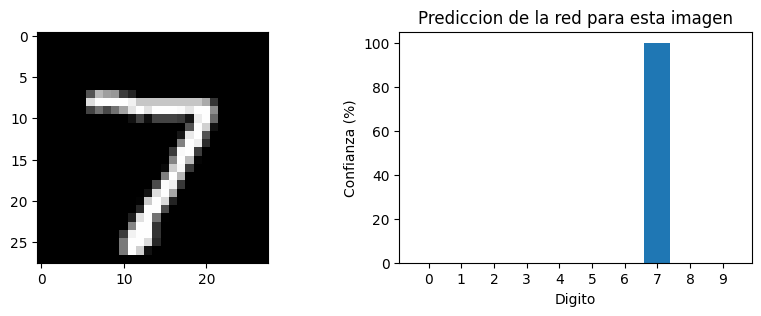

In [ ]:
i=0

probs = modelo.predict(X_test[i:i+1], verbose=0)[0] #predice la probabilidad de cada clase para la imagen i del test

fig, ax = plt.subplots(1, 2, figsize=(10, 3)) #crea dos minigraficos para mostrar la imagen del test y las probabilidades de cada clase
ax[0].imshow(X_test[i], cmap='gray') #muestra la imagen del test
ax[1].bar(range(10), probs*100) #muestra un grafico de barras con las probabilidades de cada clase
ax[1].set_xticks(range(10)) #pone los numeros del 0 al 9 en el eje x del grafico de barras
ax[1].set_xlabel('Digito'); ax[1].set_ylabel('Confianza (%)')
ax[1].set_title('Prediccion de la red para esta imagen')
plt.show()

### EJERCICIO 1
Elige una imagen cualquiera del test (cambia el índice `i`), **predícela** y responde en el chat:
1. ¿Qué dígito dice la red?
2. ¿Con qué % de confianza?
3. ¿Acierta?

Imagen del test numero 1234 la red dice 8 con una confianza del 97.5 % y la etiqueta real es 8


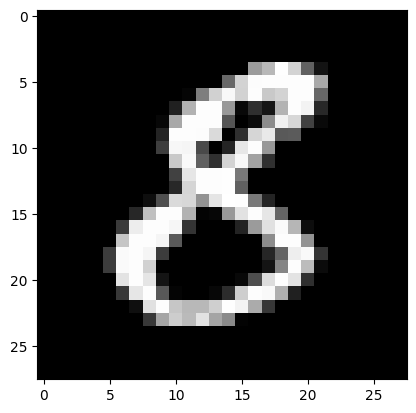

In [15]:
i = 1234

probs = modelo.predict(X_test[i:i+1], verbose=0)[0] #predice la probabilidad de cada clase para la imagen i del test
pred = int(probs.argmax()) #argmax devuelve el indice de la clase con mayor probabilidad, es decir, lo que la red "cree" que es cada imagen

print('Imagen del test numero', i, 'la red dice', pred, 'con una confianza del',
       round(float(probs[pred])*100, 1), '%', 'y la etiqueta real es', y_test[i])

plt.imshow(X_test[i], cmap='gray')
plt.show()


In [16]:
# Definimos una FUNCION para no repetir codigo. Recibe 3 parametros con valor por defecto:
#   neuronas -> cuantas neuronas tiene cada capa oculta
#   capas    -> cuantas capas ocultas apilamos
#   epochs   -> cuantas vueltas de entrenamiento
def construir_y_entrenar(neuronas=128, capas=1, epochs=5):
    # Empezamos SIEMPRE igual: la entrada 28x28 y el aplanado a 784. Lo metemos en una lista:
    capas_red = [keras.layers.Input(shape=(28, 28)), keras.layers.Flatten()]

    # Anadimos a la lista tantas capas ocultas como diga 'capas', cada una con 'neuronas' neuronas.
    # range(capas) repite el bucle 'capas' veces; usamos _ porque no necesitamos el contador.
    for _ in range(capas):
        capas_red.append(keras.layers.Dense(neuronas, activation='relu'))

    # La SALIDA es siempre igual: 10 neuronas con softmax (una por digito). La anadimos al final.
    capas_red.append(keras.layers.Dense(10, activation='softmax'))

    red = keras.Sequential(capas_red)                # construimos la red con la lista de capas
    red.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    # verbose=2 -> imprime solo 1 linea por epoch (mas limpio que la barra de progreso por defecto).
    red.fit(X_train, y_train, epochs=epochs, validation_split=0.1, verbose=2)
    acc = red.evaluate(X_test, y_test, verbose=0)[1] # accuracy en test
    print('>> Accuracy en test:', round(acc * 100, 2), '%')
    return red, acc                                  # devolvemos la red entrenada y su accuracy

# Probamos una red mas grande: 2 capas ocultas de 256 neuronas cada una.
# (Recibimos 2 valores porque la funcion devuelve 2; el '_' significa "este no lo uso".)
red_grande, _ = construir_y_entrenar(neuronas=256, capas=2, epochs=5)

Epoch 1/5
1688/1688 - 5s - 3ms/step - accuracy: 0.9371 - loss: 0.2096 - val_accuracy: 0.9680 - val_loss: 0.1055
Epoch 2/5
1688/1688 - 4s - 2ms/step - accuracy: 0.9728 - loss: 0.0864 - val_accuracy: 0.9752 - val_loss: 0.0813
Epoch 3/5
1688/1688 - 4s - 2ms/step - accuracy: 0.9810 - loss: 0.0597 - val_accuracy: 0.9780 - val_loss: 0.0762
Epoch 4/5
1688/1688 - 4s - 2ms/step - accuracy: 0.9851 - loss: 0.0462 - val_accuracy: 0.9798 - val_loss: 0.0797
Epoch 5/5
1688/1688 - 4s - 2ms/step - accuracy: 0.9886 - loss: 0.0338 - val_accuracy: 0.9760 - val_loss: 0.0985
>> Accuracy en test: 97.53 %


### EJERCICIO 2 --> Competición de accuracy
Usa `construir_y_entrenar(...)` con los valores que quieras e intenta sacar el **mejor accuracy posible**. **Pega tu resultado en el chat** y hacemos un ranking en directo.

Prueba a cambiar `neuronas`, `capas` y `epochs`. ¿Más grande es siempre mejor? ¿A partir de cuándo ya no mejora (y solo tarda más)?

In [17]:
mi_red, mi_acc = construir_y_entrenar(neuronas=512, capas=2, epochs=8)

Epoch 1/8
1688/1688 - 13s - 7ms/step - accuracy: 0.9414 - loss: 0.1932 - val_accuracy: 0.9668 - val_loss: 0.1024
Epoch 2/8
1688/1688 - 10s - 6ms/step - accuracy: 0.9749 - loss: 0.0837 - val_accuracy: 0.9778 - val_loss: 0.0768
Epoch 3/8
1688/1688 - 9s - 5ms/step - accuracy: 0.9813 - loss: 0.0572 - val_accuracy: 0.9765 - val_loss: 0.0836
Epoch 4/8
1688/1688 - 9s - 5ms/step - accuracy: 0.9867 - loss: 0.0434 - val_accuracy: 0.9788 - val_loss: 0.0817
Epoch 5/8
1688/1688 - 7s - 4ms/step - accuracy: 0.9893 - loss: 0.0336 - val_accuracy: 0.9730 - val_loss: 0.1099
Epoch 6/8
1688/1688 - 7s - 4ms/step - accuracy: 0.9899 - loss: 0.0316 - val_accuracy: 0.9812 - val_loss: 0.0818
Epoch 7/8
1688/1688 - 7s - 4ms/step - accuracy: 0.9914 - loss: 0.0267 - val_accuracy: 0.9805 - val_loss: 0.0802
Epoch 8/8
1688/1688 - 7s - 4ms/step - accuracy: 0.9930 - loss: 0.0221 - val_accuracy: 0.9828 - val_loss: 0.0820
>> Accuracy en test: 97.86 %


MNIST --> Números
FASHION_MNIST--> ROPA, 10 tipos

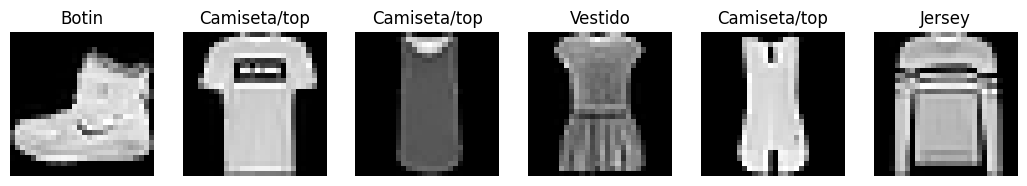

In [18]:
# 🟦 DEMO - Cargamos Fashion-MNIST. Mismo formato que MNIST (28x28 gris), pero son PRENDAS de ropa.
(Xf_train, yf_train), (Xf_test, yf_test) = keras.datasets.fashion_mnist.load_data()

# Aqui las etiquetas 0-9 son TIPOS DE ROPA, no numeros. Esta lista traduce cada numero a su nombre:
#   (la posicion 0 de la lista es el nombre de la etiqueta 0, la 1 el de la etiqueta 1, etc.)
clases = ['Camiseta/top', 'Pantalon', 'Jersey', 'Vestido', 'Abrigo',
          'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botin']

fig, ax = plt.subplots(1, 6, figsize=(13, 2.5))
for k in range(6):
    ax[k].imshow(Xf_train[k], cmap='gray')
    ax[k].set_title(clases[yf_train[k]])             # clases[etiqueta] -> el NOMBRE en vez del numero
    ax[k].axis('off')
plt.show()

Entrenar una red que clasifique ropa

Tienes `Xf_train, yf_train, Xf_test, yf_test` y la lista `clases`. Aprovecha lo que vimos y reusa codigo y dime:

- ¿Qué accuracy consigues? (la ropa es más difícil que los dígitos, ronda el 85-90%)
- Predice una prenda del test y enseña la imagen con su nombre.


In [ ]:
# 1) normaliza Xf_train y Xf_test (dividir entre 255)
# 2) construye una red Sequential (Input 28x28 -> Flatten -> Dense relu -> Dense 10 softmax)
# 3) compila (optimizer adam, loss sparse_categorical_crossentropy, metrics accuracy)
# 4) entrena con fit
# 5) evalua con evaluate

# TODO

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8213 - loss: 0.5144 - val_accuracy: 0.8467 - val_loss: 0.4170
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8623 - loss: 0.3821 - val_accuracy: 0.8713 - val_loss: 0.3670
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8762 - loss: 0.3427 - val_accuracy: 0.8622 - val_loss: 0.3600
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8840 - loss: 0.3172 - val_accuracy: 0.8812 - val_loss: 0.3274
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8903 - loss: 0.2996 - val_accuracy: 0.8795 - val_loss: 0.3303
Accuracy en test (ropa): 87.6 %


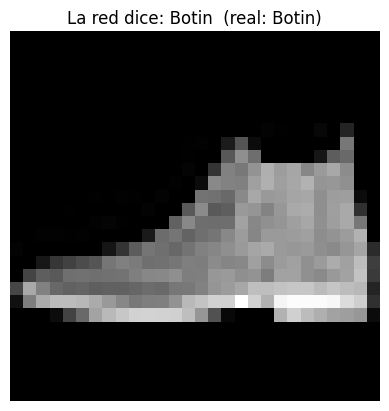

In [19]:
# -- SOLUCION Reto --
Xf_train = Xf_train / 255.0                            # 1) normalizar (mismo motivo que en MNIST: numeros 0-1)
Xf_test  = Xf_test  / 255.0

red_ropa = keras.Sequential([                          # 2) construir (MISMA estructura que el Bloque 1)
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10,  activation='softmax'),
])
red_ropa.compile(optimizer='adam',                     # 3) compilar (identico a MNIST)
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
red_ropa.fit(Xf_train, yf_train, epochs=5, validation_split=0.1)   # 4) entrenar
acc = red_ropa.evaluate(Xf_test, yf_test, verbose=0)[1]           # 5) evaluar (accuracy en test)
print('Accuracy en test (ropa):', round(acc * 100, 1), '%')

# Predecimos una prenda y la ensenamos con su NOMBRE (traduciendo la etiqueta con la lista 'clases'):
i = 0
pred = int(red_ropa.predict(Xf_test[i:i+1], verbose=0).argmax())   # digito/clase predicha
plt.imshow(Xf_test[i], cmap='gray'); plt.axis('off')
plt.title('La red dice: ' + clases[pred] + '  (real: ' + clases[yf_test[i]] + ')')
plt.show()

YOLO -> Red neuronal, pero gigante y ya viene entrenada.

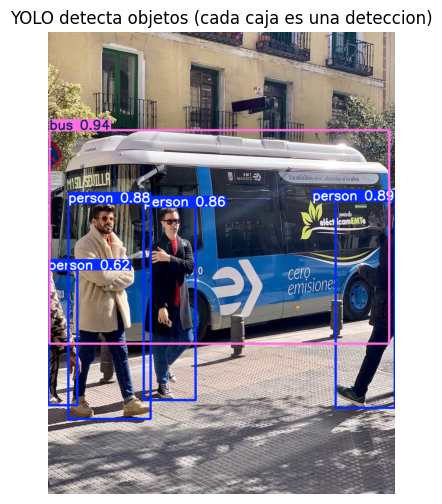

Objetos detectados:
 - bus
 - person
 - person
 - person
 - person


In [20]:
# 🟦 DEMO - YOLO sobre una foto. Solo lo USAMOS (ya viene entrenado por otros); no entrenamos nada.
from ultralytics import YOLO            # YOLO = modelo de deteccion de objetos, listo para usar
import urllib.request, os

if not os.path.exists('foto.jpg'):      # si no tenemos la foto de ejemplo, la descargamos
    urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg', 'foto.jpg')

modelo_yolo = YOLO('yolo11n.pt')        # carga el modelo. 'n' = nano (el mas ligero). Se baja solo la 1a vez.
resultado = modelo_yolo('foto.jpg', verbose=False)   # le pasamos la foto. verbose=False -> sin detalles tecnicos

# resultado[0] = el analisis de nuestra (unica) imagen.  .plot() = la imagen con las cajas YA dibujadas.
anotada = resultado[0].plot()           # devuelve un array de pixeles en orden BGR (azul-verde-rojo)
plt.figure(figsize=(8, 6))
plt.imshow(anotada[:, :, ::-1])         # [:, :, ::-1] invierte el ultimo eje: pasa de BGR a RGB para verla bien
plt.axis('off'); plt.title('YOLO detecta objetos (cada caja es una deteccion)')
plt.show()

print('Objetos detectados:')
for c in resultado[0].boxes.cls:        # boxes.cls = lista con la clase (un numero) de cada caja detectada
    print(' -', modelo_yolo.names[int(c)])   # .names traduce ese numero a su nombre ('person', 'bus'...)

### Ejercicio -  cargar una foto que querais

In [ ]:
import cv2
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
while True:
    ok, frame = cap.read()
    if not ok: break
    cv2.imshow('YOLO - q para salir', modelo_yolo(frame, verbose=False)[0].plot())
    if cv2.waitKey(1) & 0xFF == ord('q'): break
cap.release(); cv2.destroyAllWindows()